Key Findings
- VIP customers generate the highest revenue despite being a smaller group.
- Loyal customers contribute consistently to sales.
- At-risk customers represent an opportunity for re-engagement strategies.
- New customers show potential for future growth.

In [15]:
rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

Segment
New        7682160.913
At Risk    1010710.631
VIP         218536.360
Name: Monetary, dtype: float64

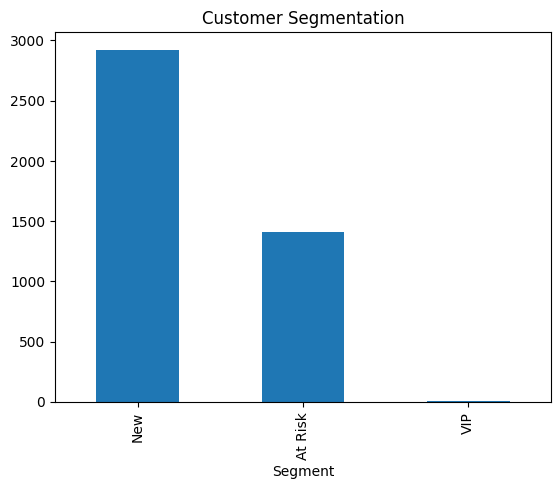

In [14]:
rfm["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segmentation")
plt.show()

In [13]:
rfm["Segment"].value_counts()

Segment
New        2922
At Risk    1413
VIP           3
Name: count, dtype: int64

In [12]:
def segment(row):
    if row["R_score"] == 4 and row["F_score"] >= 3:
        return "VIP"
    elif row["F_score"] >= 3:
        return "Loyal"
    elif row["R_score"] == 4:
        return "New"
    else:
        return "At Risk"

rfm["Segment"] = rfm.apply(segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,2,112,At Risk
12347.0,2,7,4310.00,4,1,1,411,New
12348.0,75,4,1797.24,4,1,1,411,New
12349.0,19,1,1757.55,4,1,1,411,New
12350.0,310,1,334.40,1,1,1,111,At Risk


In [11]:
rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,2,112
12347.0,2,7,4310.00,4,1,1,411
12348.0,75,4,1797.24,4,1,1,411
12349.0,19,1,1757.55,4,1,1,411
12350.0,310,1,334.40,1,1,1,111


In [10]:
rfm["R_score"] = pd.cut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.cut(rfm["Frequency"], 4, labels=[1,2,3,4])
rfm["M_score"] = pd.cut(rfm["Monetary"], 4, labels=[1,2,3,4])

In [6]:
import pandas as pd

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")

df = df.dropna(subset=["CustomerID", "Description"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["CustomerID"] = df["CustomerID"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
